# Principal Component Analysis (PCA)

## Learning Notes & Practical Implementation

PCA is an **unsupervised dimensionality-reduction technique**. It transforms many original features into a smaller set of new features called **Principal Components**.

### Main goals
- Reduce the number of dimensions.
- Preserve as much variance as possible.
- Remove redundancy from correlated features.
- Make high-dimensional data easier to visualize.
- Sometimes reduce computational cost.

> **Important:** PCA creates new features; it does not simply select the most important original features.


## 1. Why Do We Need PCA?

A dataset can contain many features, and some may contain similar information.

For example:

```text
Feature 1 ──┐
Feature 2 ──┤
Feature 3 ──┤  Similar information
Feature 4 ──┘
```

Using all of them can make models more expensive and high-dimensional data difficult to visualize.

PCA tries to represent the important structure of the data using fewer dimensions.


## 2. Main Idea

PCA finds new directions in the data that capture the most variance.

These directions are called **Principal Components**.

- **PC1** captures the greatest variance.
- **PC2** captures the greatest remaining variance while being orthogonal to PC1.
- The process continues for additional components.

```text
PC1 → Maximum variance
PC2 → Maximum remaining variance
PC3 → Next remaining variance
...
```


## 3. Principal Components

A Principal Component is a new feature formed as a linear combination of the original features.

$$
PC_1 = w_1X_1 + w_2X_2 + \cdots + w_pX_p
$$

The values $w_1, w_2, ..., w_p$ are called **loadings**.

They describe how strongly each original feature contributes to the component.

> PCA does not normally keep individual original features. It creates new combinations of them.


## 4. Variance and Covariance

PCA searches for directions where the data varies the most.

It uses the relationships between features, commonly represented by a **covariance matrix**.

- Positive covariance: two features tend to increase together.
- Negative covariance: one tends to increase while the other decreases.
- Near-zero covariance: little linear relationship.

PCA uses this covariance structure to find important directions in the data.


## 5. Eigenvectors and Eigenvalues

A mathematical way to understand PCA is through the eigenvectors and eigenvalues of the covariance matrix.

### Eigenvectors
Define the directions of the principal components.

### Eigenvalues
Represent the amount of variance associated with those directions.

Larger eigenvalue → more variance captured → more important component.

The components are ordered from highest explained variance to lowest.


## 6. Explained Variance

The **explained variance ratio** tells us how much of the total variance each component captures.

Example:

```text
PC1 → 45%
PC2 → 25%
PC3 → 12%
PC4 →  8%
```

PC1 + PC2 therefore explain:

```text
45% + 25% = 70%
```

In Scikit-Learn:

```python
pca.explained_variance_ratio_
```

Cumulative explained variance helps us decide how many components to keep.


## 7. Why Feature Scaling Matters

PCA is sensitive to feature scale.

For example:

```text
Age:       18 → 80
Income:    1,000 → 100,000
```

Income has a much larger numerical scale and could dominate the variance.

Therefore, PCA is commonly applied after standardization:

```text
StandardScaler
      ↓
     PCA
```

When PCA is used in a predictive workflow, fit the scaler and PCA only on the training data.


## 8. Choosing the Number of Components

There is no universal number of components.

One common approach is to preserve a target amount of variance:

```python
PCA(n_components=0.95)
```

This keeps enough components to explain approximately 95% of the variance.

Another approach is to plot cumulative explained variance and choose a reasonable point.


## 9. PCA Workflow

```text
Load data
    ↓
Explore data
    ↓
Select numerical features
    ↓
Train/Test Split (for prediction)
    ↓
Standardize features
    ↓
Fit PCA on training data
    ↓
Transform data
    ↓
Inspect explained variance
    ↓
Choose components
    ↓
Visualize or train a model
```

For purely exploratory PCA there may be no train/test split. But when PCA is part of a predictive model, it must be fitted using training data only.


# 10. Practical Implementation

We will use the Breast Cancer dataset and reduce its 30 numerical features to a smaller number of components.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [14]:
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Shape:", X.shape)
print("Number of features:", X.shape[1])

X.describe()


Shape: (569, 30)
Number of features: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 11. Standardize the Features

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[ 1.09706398e+00, -2.07333501e+00,  1.26993369e+00,
         9.84374905e-01,  1.56846633e+00,  3.28351467e+00,
         2.65287398e+00,  2.53247522e+00,  2.21751501e+00,
         2.25574689e+00,  2.48973393e+00, -5.65265059e-01,
         2.83303087e+00,  2.48757756e+00, -2.14001647e-01,
         1.31686157e+00,  7.24026158e-01,  6.60819941e-01,
         1.14875667e+00,  9.07083081e-01,  1.88668963e+00,
        -1.35929347e+00,  2.30360062e+00,  2.00123749e+00,
         1.30768627e+00,  2.61666502e+00,  2.10952635e+00,
         2.29607613e+00,  2.75062224e+00,  1.93701461e+00],
       [ 1.82982061e+00, -3.53632408e-01,  1.68595471e+00,
         1.90870825e+00, -8.26962447e-01, -4.87071673e-01,
        -2.38458552e-02,  5.48144156e-01,  1.39236330e-03,
        -8.68652457e-01,  4.99254601e-01, -8.76243603e-01,
         2.63326966e-01,  7.42401948e-01, -6.05350847e-01,
        -6.92926270e-01, -4.40780058e-01,  2.60162067e-01,
        -8.05450380e-01, -9.94437403e-02,  1.80592744e+

## 12. Reduce to Two Principal Components

Using two components makes it possible to visualize the data in two dimensions.

In [5]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape:", X_pca.shape)


Original shape: (569, 30)
Reduced shape: (569, 2)


In [6]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()


,PC1,PC2
0,9.192837,1.948583
1,2.387802,-3.768172
2,5.733896,-1.075174
3,7.122953,10.275589
4,3.935302,-1.948072


## 13. Explained Variance

In [7]:
explained_variance = pca.explained_variance_ratio_

print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])
print("Total:", explained_variance.sum())


PC1: 0.4427202560752637
PC2: 0.18971182044033066
Total: 0.6324320765155944


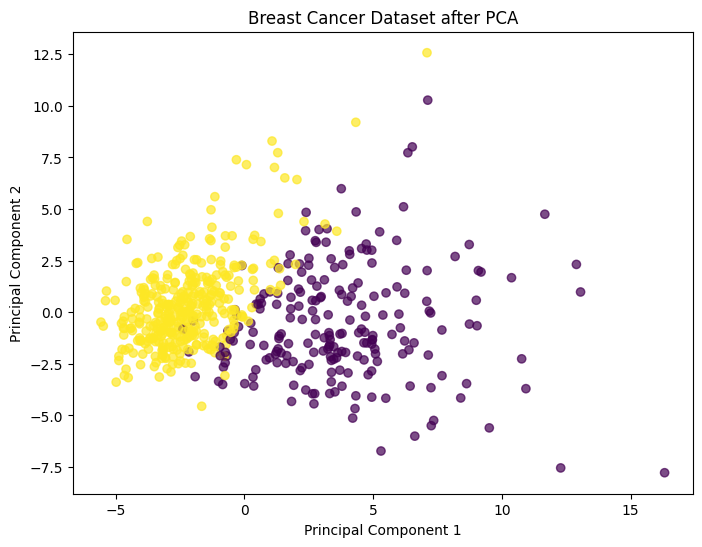

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Dataset after PCA")

plt.show()


The target labels are used only to color the visualization.

PCA itself is **unsupervised** and does not use `y` when finding the components.


## 14. Explained Variance for All Components

In [9]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Individual explained variance:")
print(explained)

print("\nCumulative explained variance:")
print(cumulative)


Individual explained variance:
[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]

Cumulative explained variance:
[0.44272026 0.63243208 0.72636371 0.79238506 0.84734274 0.88758796
 0.9100953  0.92598254 0.93987903 0.95156881 0.961366   0.97007138
 0.97811663 0.98335029 0.98648812 0.98915022 0.99113018 0.99288414
 0.9945334  0.99557204 0.99657114 0.99748579 0.99829715 0.99889898
 0.99941502 0.99968761 0.99991763 0.99997061 0.99999557 1.        ]


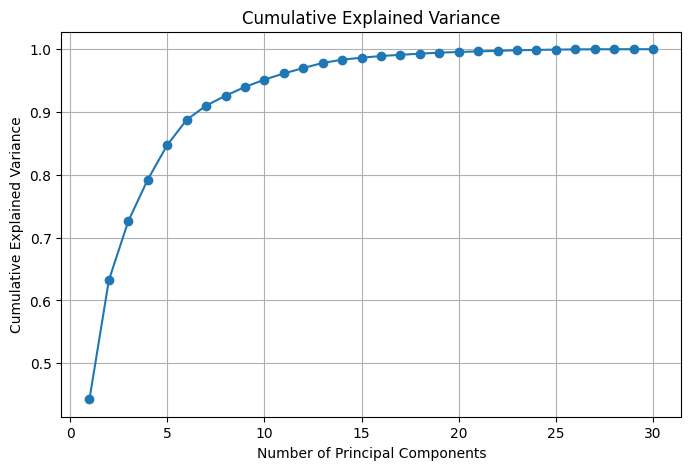

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative) + 1),
    cumulative,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.grid(True)
plt.show()


## 15. Keep 95% of the Variance

In [11]:
pca_95 = PCA(n_components=0.95)

X_pca_95 = pca_95.fit_transform(X_scaled)

print("Original number of features:", X.shape[1])
print("Number of components:", pca_95.n_components_)
print("Explained variance:", pca_95.explained_variance_ratio_.sum())


Original number of features: 30
Number of components: 10
Explained variance: 0.9515688143366667


## 16. PCA Loadings

`components_` contains the weights of the original features in each principal component.

In [12]:
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=["PC1", "PC2"]
)

loadings


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
PC1,0.218902,0.103725,0.227537,0.220995,0.142590,0.239285,0.258400,0.260854,0.138167,0.064363,...,0.227997,0.104469,0.236640,0.224871,0.127953,0.210096,0.228768,0.250886,0.122905,0.131784
PC2,-0.233857,-0.059706,-0.215181,-0.231077,0.186113,0.151892,0.060165,-0.034768,0.190349,0.366575,...,-0.219866,-0.045467,-0.199878,-0.219352,0.172304,0.143593,0.097964,-0.008257,0.141883,0.275339


### Interpreting Loadings

A large positive or negative loading means an original feature contributes strongly to a component.

The sign itself is not inherently good or bad. The magnitude and relative direction are what matter.

A principal component is usually a combination of many original features.


## 17. PCA in a Machine Learning Pipeline

PCA can be used before a machine learning model:

```text
Original Features
       ↓
StandardScaler
       ↓
PCA
       ↓
Machine Learning Model
```

For example:

```python
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("model", LogisticRegression())
])
```

Putting PCA inside the pipeline is important when using cross-validation because PCA must be fitted separately inside each training fold.


# 18. Advantages

- Reduces dimensionality.
- Can remove redundancy from correlated features.
- Makes high-dimensional data easier to visualize.
- Can reduce computational cost.
- Can sometimes improve model performance.
- Produces orthogonal principal components.

# 19. Disadvantages

- Principal components are harder to interpret than original features.
- Sensitive to feature scaling.
- Sensitive to outliers.
- Too much dimensionality reduction can discard useful information.
- PCA maximizes variance, not predictive performance.
- The best number of components depends on the problem.

# 20. Final Summary

PCA transforms the original features into a new set of principal components.

The components are ordered by the amount of variance they capture.

```text
Original Features
       ↓
Standardize
       ↓
Find directions of maximum variance
       ↓
Principal Components
       ↓
Keep selected components
       ↓
Lower-dimensional representation
```

### Key concepts

```text
Variance
   ↓
Covariance
   ↓
Eigenvectors
   ↓
Eigenvalues
   ↓
Principal Components
   ↓
Explained Variance
   ↓
Dimensionality Reduction
```

> **Most important practical rule:** Scale features before PCA when their scales differ, and fit PCA only on training data when using it in a predictive workflow.
